In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [ ]:
class WarehouseRobotEnv:
    def __init__(self, rows=6, cols=6, max_battery=12):
        self.rows = rows
        self.cols = cols
        self.max_battery = max_battery

        self.start = (0, 0)
        self.package_pos = (1, 4)
        self.goal = (5, 5)
        self.charge_station = (4, 1)

        self.obstacles = {
            (1, 1), (1, 2),
            (2, 3),
            (3, 3), (4, 3),
            (3, 5)
        }

        self.action_space = 6
        self.reset()

    def reset(self):
        self.robot_pos = self.start
        self.has_package = 0
        self.battery = self.max_battery
        self.done = False
        return self.get_state()

    def get_state(self):
        r, c = self.robot_pos
        return (r, c, self.has_package, self.battery)

    def step(self, action):
        if self.done:
            return self.get_state(), 0, True

        reward = -1  # default step penalty
        r, c = self.robot_pos

        # movement actions consume battery
        if action in [0, 1, 2, 3]:
            if self.battery <= 0:
                self.done = True
                return self.get_state(), -100, True

            nr, nc = r, c
            if action == 0:   # up
                nr -= 1
            elif action == 1: # down
                nr += 1
            elif action == 2: # left
                nc -= 1
            elif action == 3: # right
                nc += 1

            self.battery -= 1

            if nr < 0 or nr >= self.rows or nc < 0 or nc >= self.cols or (nr, nc) in self.obstacles:
                reward = -4
            else:
                self.robot_pos = (nr, nc)

        elif action == 4:  # pick package
            if self.robot_pos == self.package_pos and self.has_package == 0:
                self.has_package = 1
                reward = 25
            else:
                reward = -3

        elif action == 5:  # charge
            if self.robot_pos == self.charge_station:
                if self.battery < self.max_battery:
                    self.battery = self.max_battery
                    reward = 8
                else:
                    reward = -2
            else:
                reward = -3

        # delivery check
        if self.robot_pos == self.goal and self.has_package == 1:
            reward = 100
            self.done = True

        # battery-dead check
        if self.battery <= 0 and not self.done:
            self.done = True
            reward = -100

        return self.get_state(), reward, self.done

    def render(self):
        grid = np.zeros((self.rows, self.cols))

        for (r, c) in self.obstacles:
            grid[r, c] = -1

        pr, pc = self.package_pos
        gr, gc = self.goal
        cr, cc = self.charge_station
        rr, rc = self.robot_pos

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid, cmap='Pastel1')

        # draw cells
        for i in range(self.rows):
            for j in range(self.cols):
                text = ""
                if (i, j) in self.obstacles:
                    text = "X"
                elif (i, j) == self.package_pos and self.has_package == 0:
                    text = "P"
                elif (i, j) == self.goal:
                    text = "G"
                elif (i, j) == self.charge_station:
                    text = "C"

                if (i, j) == self.robot_pos:
                    text = "R"

                ax.text(j, i, text, ha='center', va='center', fontsize=16, fontweight='bold')

        ax.set_xticks(np.arange(-0.5, self.cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.rows, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        status = f"Battery: {self.battery} | Package: {self.has_package} | Position: {self.robot_pos}"
        ax.set_title(status, fontsize=12)
        plt.show()

In [ ]:
class SARSALambdaAgent:
    def __init__(self, env, alpha=0.1, gamma=0.95, lam=0.8, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.state_size = env.rows * env.cols * 2 * (env.max_battery + 1)
        self.action_size = env.action_space

        self.Q = np.zeros((self.state_size, self.action_size))

    def state_to_index(self, state):
        r, c, has_package, battery = state
        idx = r
        idx = idx * self.env.cols + c
        idx = idx * 2 + has_package
        idx = idx * (self.env.max_battery + 1) + battery
        return idx

    def choose_action(self, state):
        s_idx = self.state_to_index(state)
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.Q[s_idx])

    def train(self, episodes=500):
        rewards_per_episode = []

        for ep in range(episodes):
            state = self.env.reset()
            s_idx = self.state_to_index(state)
            action = self.choose_action(state)

            E = np.zeros_like(self.Q)  # eligibility traces
            total_reward = 0

            while True:
                next_state, reward, done = self.env.step(action)
                ns_idx = self.state_to_index(next_state)
                next_action = self.choose_action(next_state) if not done else 0

                td_target = reward if done else reward + self.gamma * self.Q[ns_idx, next_action]
                td_error = td_target - self.Q[s_idx, action]

                E[s_idx, action] += 1
                self.Q += self.alpha * td_error * E
                E *= self.gamma * self.lam

                s_idx = ns_idx
                action = next_action
                total_reward += reward

                if done:
                    break

            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            rewards_per_episode.append(total_reward)

            if (ep + 1) % 50 == 0:
                avg_last = np.mean(rewards_per_episode[-50:])
                print(f"Episode {ep+1}/{episodes}, Avg Reward (last 50): {avg_last:.2f}, Epsilon: {self.epsilon:.3f}")

        return rewards_per_episode

    def greedy_action(self, state):
        s_idx = self.state_to_index(state)
        return np.argmax(self.Q[s_idx])

In [ ]:
env = WarehouseRobotEnv()
agent = SARSALambdaAgent(
    env,
    alpha=0.1,
    gamma=0.95,
    lam=0.8,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

rewards = agent.train(episodes=400)

Episode 50/400, Avg Reward (last 50): -143.88, Epsilon: 0.778
Episode 100/400, Avg Reward (last 50): -140.28, Epsilon: 0.606
Episode 150/400, Avg Reward (last 50): -143.04, Epsilon: 0.471
Episode 200/400, Avg Reward (last 50): -142.84, Epsilon: 0.367
Episode 250/400, Avg Reward (last 50): -144.30, Epsilon: 0.286
Episode 300/400, Avg Reward (last 50): 19.28, Epsilon: 0.222
Episode 350/400, Avg Reward (last 50): 2895.00, Epsilon: 0.173
Episode 400/400, Avg Reward (last 50): 28815.34, Epsilon: 0.135


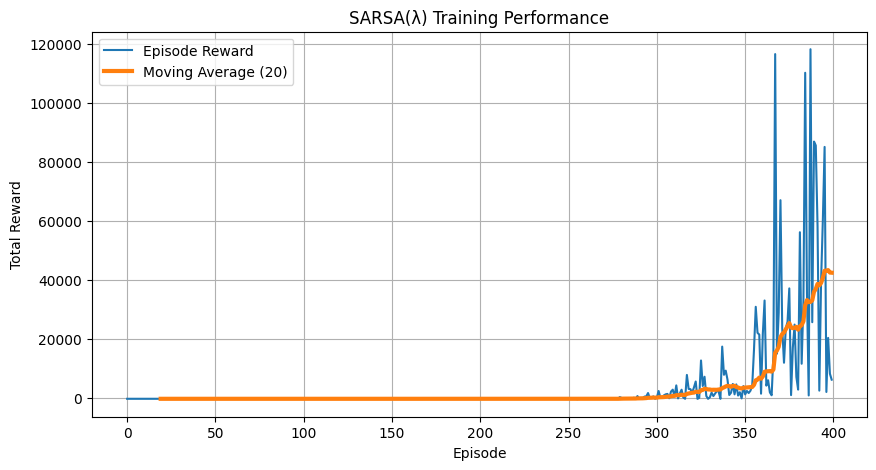

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(rewards, label='Episode Reward')
window = 20
moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), moving_avg, linewidth=3, label='Moving Average (20)')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA(λ) Training Performance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
action_symbols = {
    0: '↑',
    1: '↓',
    2: '←',
    3: '→',
    4: 'P',
    5: 'C'
}

def show_policy(agent, has_package=0, battery=None):
    if battery is None:
        battery = agent.env.max_battery

    rows, cols = agent.env.rows, agent.env.cols
    print(f"Policy View | has_package={has_package}, battery={battery}\n")

    for r in range(rows):
        row_syms = []
        for c in range(cols):
            if (r, c) in agent.env.obstacles:
                row_syms.append(" X ")
            else:
                state = (r, c, has_package, battery)
                a = agent.greedy_action(state)
                row_syms.append(f" {action_symbols[a]} ")
        print("".join(row_syms))

show_policy(agent, has_package=0, battery=env.max_battery)

Policy View | has_package=0, battery=12

 ↓  ↑  ↑  ↑  ↑  ↑ 
 ↑  X  X  ↑  ↑  ↑ 
 ↑  ↑  ↑  X  ↑  ↑ 
 ↑  ↑  ↑  X  ↑  X 
 ↑  ←  ↑  X  ↑  ↑ 
 ↑  ↑  ↑  ↑  ↑  ↑ 


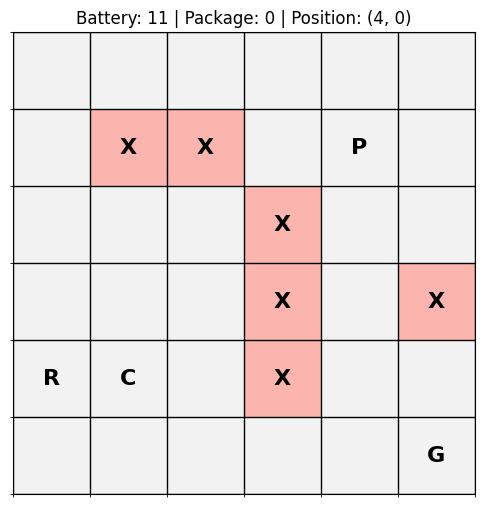

Step: 100
Chosen Action: RIGHT
Reward: -1
Total Reward: 179


In [ ]:
def simulate_agent(env, agent, delay=3.6, max_steps=100):
    state = env.reset()
    total_reward = 0

    print("Starting live simulation...\n")
    time.sleep(1)

    for step in range(max_steps):
        clear_output(wait=True)
        env.render()

        action = agent.greedy_action(state)
        action_name = ["UP", "DOWN", "LEFT", "RIGHT", "PICK", "CHARGE"][action]
        print(f"Step: {step+1}")
        print(f"Chosen Action: {action_name}")

        next_state, reward, done = env.step(action)
        total_reward += reward
        print(f"Reward: {reward}")
        print(f"Total Reward: {total_reward}")

        state = next_state
        time.sleep(delay)

        if done:
            clear_output(wait=True)
            env.render()
            print("Simulation finished.")
            print(f"Final Total Reward: {total_reward}")
            if env.robot_pos == env.goal and env.has_package == 1:
                print("Task completed successfully: Package delivered.")
            else:
                print("Task failed.")
            break

simulate_agent(env, agent, delay=0.7)